# Kou jump-diffusion: asymmetric double-exponential jumps

Merton's jumps are normal in log-space. That has two limitations: a normal is
symmetric in shape (up and down jumps differ only in mean, not form), and it has
thin Gaussian tails. Real markets crash more sharply than they rally, and their
extreme moves are fatter-tailed than a Gaussian jump captures.

Kou (2002) replaces the normal jump with an asymmetric double-exponential. This
notebook derives the Kou characteristic function, then implements and validates
it, reusing the model-agnostic COS core and the Monte Carlo validation pattern
built for Merton. The only genuinely new derivation is the single-jump
characteristic function; pricing and validation are reuse.

## 1. The model

Same diffusion-plus-compound-Poisson structure as Merton, differing only in the
jump size distribution:

$$d(\log S_t) = \left(r - q - \tfrac12\sigma^2 - \lambda\kappa\right)dt
+ \sigma\, dW_t + dJ_t$$

The jump size $Y$ (in log-space) follows an **asymmetric double-exponential**:

$$f_Y(y) = p\,\eta_1 e^{-\eta_1 y}\mathbf{1}_{y \ge 0}
+ (1-p)\,\eta_2 e^{\eta_2 y}\mathbf{1}_{y < 0}$$

Two one-sided exponentials glued at zero:

- With probability $p$: an **up-jump**, $\text{Exp}(\eta_1)$, mean size $1/\eta_1$.
- With probability $1-p$: a **down-jump**, $\text{Exp}(\eta_2)$, mean size $1/\eta_2$.

Jump parameters: intensity $\lambda$ (jumps/year), up-probability $p$, up-rate
$\eta_1$, down-rate $\eta_2$. Four jump parameters vs Merton's two.

What the extra parameters buy:

- **Asymmetry of shape.** $\eta_1 \ne \eta_2$ makes up- and down-jumps genuinely
  different in form, not just mean. Typically $\eta_2 < \eta_1$ (down-jumps decay
  slower, so fatter) and $p < 0.5$ (down-jumps more likely): structural crash
  asymmetry.
- **Fatter tails.** Exponential tails are heavier than Gaussian, so extreme
  jumps are more probable, matching the deep-wing richness of real option prices.
- **Exotic tractability.** The double-exponential's memorylessness makes barrier
  and lookback options analytically tractable under Kou where they are not under
  Merton. Not used in this European calibration, but it is why Kou is prized.

### The constraint $\eta_1 > 1$

The up-rate must exceed 1. The reason surfaces in the compensator below: it
involves $E[e^Y]$, and for an up-jump $e^Y$ with $Y \sim \text{Exp}(\eta_1)$ that
expectation only converges if $\eta_1 > 1$. Economically, up-jumps cannot be so
fat-tailed that the expected price multiplier diverges. It is the Kou analogue of
"the jump has finite mean," and violating it makes $\kappa$ blow up.

## 2. No-arbitrage and the compensator (the FTAP thread)

The compensator $-\lambda\kappa$ in the drift is not cosmetic; it is what makes
the model arbitrage-free. The chain of reasoning ties back to the Fundamental
Theorem of Asset Pricing.

FTAP: no arbitrage holds iff there is an equivalent measure under which the
*discounted* price is a martingale. Writing the model under the risk-neutral
measure $\mathbb{Q}$ asserts we are in that measure, so we require

$$E^{\mathbb{Q}}[S_T] = S_0 e^{(r-q)T}$$

Jumps add expected growth: each jump multiplies the price by $e^Y$, and
$E[e^Y] \ne 1$ in general. Left uncorrected, this pushes $E[S_T]$ above
$S_0 e^{(r-q)T}$, breaking the martingale property and admitting arbitrage. The
compensator removes exactly that excess growth:

$$\kappa = E[e^Y - 1] = E[e^Y] - 1$$

is the expected proportional price change per jump, $\lambda\kappa$ is the
expected jump growth rate, and subtracting it in the drift restores the
martingale.

### $\phi(-i)$ computes it, and checks it

The characteristic function is $\phi(u) = E[e^{iu \log S_T}]$. At $u = -i$,
$e^{iu \log S_T} = e^{\log S_T} = S_T$, so $\phi(-i) = E[S_T]$, which must equal
$S_0 e^{(r-q)T}$. The same trick at the jump level: the single-jump char func is
$\hat f(u) = E[e^{iuY}]$, so $\hat f(-i) = E[e^Y]$, giving

$$\kappa = \hat f(-i) - 1$$

So $u = -i$ turns the char func's $e^{iuY}$ into the price multiplier $e^Y$. This
is both how the compensator is computed and how the martingale property is
verified (evaluate $\phi(-i)$, confirm it equals $S_0 e^{(r-q)T}$), which becomes
a validation gate.

## 3. The characteristic function, derived

Same Levy-Khintchine structure as Merton, since the compound-Poisson form is
identical and only the jump size distribution changed:

$$\phi_{\text{Kou}}(u) = \phi_{\text{diffusion}}(u) \cdot
\exp\!\Big(\lambda\tau\big[\hat f(u) - 1\big]\Big)$$

The diffusion factor is the known BSM Gaussian (with jump-compensated drift). The
only new work is $\hat f(u)$, the char func of a single double-exponential jump.

### The single-jump char func

By definition $\hat f(u) = E[e^{iuY}] = \int_{-\infty}^{\infty} e^{iuy} f_Y(y)\,dy$.
Split at zero into the up and down pieces. Each is a standard one-sided
exponential integral:

$$\int_0^\infty \eta e^{-\eta y} e^{iuy}\,dy = \frac{\eta}{\eta - iu}$$

Applying it to each side (the down-jump lives on $y < 0$, flipping the sign on
$iu$), weighted by the up/down probabilities:

$$\hat f(u) = \frac{p\,\eta_1}{\eta_1 - iu} + \frac{(1-p)\,\eta_2}{\eta_2 + iu}$$

The two denominators carry opposite signs on $iu$ because the up-jump is
supported on $[0,\infty)$ and the down-jump on $(-\infty, 0)$.

### The compensator

From $\kappa = \hat f(-i) - 1$, substitute $u = -i$ (so $iu = 1$ in the first
denominator, $iu = 1$ flips to $-1$... careful with signs):

$$\kappa = \frac{p\,\eta_1}{\eta_1 - 1} + \frac{(1-p)\,\eta_2}{\eta_2 + 1} - 1$$

The $\eta_1 - 1$ in the first denominator is exactly where the $\eta_1 > 1$
constraint bites: at $\eta_1 = 1$ it is a division by zero, and below it the term
goes negative, an unphysical expected up-jump multiplier. (No constraint on
$\eta_2$ beyond $\eta_2 > 0$, since $\eta_2 + 1$ is always safe; down-jumps shrink
the price by a bounded factor.)

### The full Kou char func

$$\phi_{\text{Kou}}(u) = \exp\!\Big(iu\big(\log S_0 + (r - q - \tfrac12\sigma^2
- \lambda\kappa)\tau\big) - \tfrac12\sigma^2 u^2\tau\Big)
\cdot \exp\!\Big(\lambda\tau\big[\hat f(u) - 1\big]\Big)$$

Same sanity checks as Merton, each a validation gate: $\lambda \to 0$ recovers
BSM; $\phi(-i) = S_0 e^{(r-q)T}$ certifies $\kappa$; $\phi(0) = 1$.

## 4. The cumulants

Diffusion and jump cumulants add (independence), as for Merton. The diffusion
cumulants are BSM's; the jump cumulants come from the compound-Poisson moments
of the double-exponential.

The single-jump moments (mean and second moment of $Y$):

$$E[Y] = \frac{p}{\eta_1} - \frac{1-p}{\eta_2}, \qquad
E[Y^2] = \frac{2p}{\eta_1^2} + \frac{2(1-p)}{\eta_2^2}$$

($E[Y]$ is the probability-weighted up-mean minus down-mean; $E[Y^2]$ uses that
$\text{Exp}(\eta)$ has second moment $2/\eta^2$.) Then, exactly as for Merton:

$$c_1 = \log S_0 + \left(r - q - \tfrac12\sigma^2 - \lambda\kappa\right)\tau
+ \lambda\tau\, E[Y]$$

$$c_2 = \sigma^2\tau + \lambda\tau\, E[Y^2]$$

The jump variance is $\lambda\tau\, E[Y^2]$, the compound-Poisson second moment,
same structure as Merton's $\lambda\tau(\mu_J^2 + \delta_J^2)$ but with the
double-exponential moments. Getting $E[Y^2]$ right (both the $2/\eta^2$ factors)
keeps the truncation range and thus the wings accurate.

In [1]:
from models.kou import kou_char_func, kou_cumulants
import numpy as np

S0, r, q, T = 100.0, 0.03, 0.01, 0.5
sigma, lam, p, eta1, eta2 = 0.20, 0.5, 0.4, 10.0, 5.0

# 1. martingale: phi(-i) = S0 exp((r-q)T)
phi = kou_char_func(np.array([-1j]), S0, r, q, T, sigma, lam, p, eta1, eta2)[0]
print(f"phi(-i)={phi.real:.6f}, expected={S0*np.exp((r-q)*T):.6f}")

# 2. BSM reduction of cumulants at lam=0
c1, c2 = kou_cumulants(S0, r, q, T, sigma, lam=0.0, p=p, eta1=eta1, eta2=eta2)
print(f"c1={c1:.6f}, expected={np.log(S0)+(r-q-0.5*sigma**2)*T:.6f}")
print(f"c2={c2:.6f}, expected={sigma**2*T:.6f}")

phi(-i)=101.005017, expected=101.005017
c1=4.605170, expected=4.605170
c2=0.020000, expected=0.020000


In [2]:
from models.kou import kou_simulate_terminal
from pricing.fourier import kou_cos_price
S0, r, q, T = 100.0, 0.03, 0.01, 0.5
sigma, lam, p, eta1, eta2 = 0.20, 0.5, 0.4, 10.0, 5.0
K = 100.0

call = kou_cos_price(S0, r, q, T, sigma, lam, p, eta1, eta2, K, "call")
put  = kou_cos_price(S0, r, q, T, sigma, lam, p, eta1, eta2, K, "put")

# check each against MC independently (MC prices both call and put from same paths)
ST = kou_simulate_terminal(S0, r, q, T, sigma, lam, p, eta1, eta2, 5_000_000, seed=1)
mc_call = np.exp(-r*T) * np.maximum(ST - K, 0).mean()
mc_put  = np.exp(-r*T) * np.maximum(K - ST, 0).mean()

print(f"call  COS={call:.5f}  MC={mc_call:.5f}  diff={call-mc_call:+.5f}")
print(f"put   COS={put:.5f}  MC={mc_put:.5f}  diff={put-mc_put:+.5f}")
print(f"parity lhs={call-put:.6f}  rhs={S0*np.exp(-q*T)-K*np.exp(-r*T):.6f}")

call  COS=7.06282  MC=7.07108  diff=-0.00826
put   COS=6.07257  MC=6.06778  diff=+0.00479
parity lhs=0.990247  rhs=0.990054


In [3]:
for L in [10, 14, 20]:
    call = kou_cos_price(S0, r, q, T, sigma, lam, p, eta1, eta2, K, "call", L=L)
    put  = kou_cos_price(S0, r, q, T, sigma, lam, p, eta1, eta2, K, "put", L=L)
    print(f"L={L}: parity residual = {(call-put) - (S0*np.exp(-q*T)-K*np.exp(-r*T)):.2e}")

L=10: parity residual = 1.93e-04
L=14: parity residual = 2.87e-06
L=20: parity residual = 5.10e-09


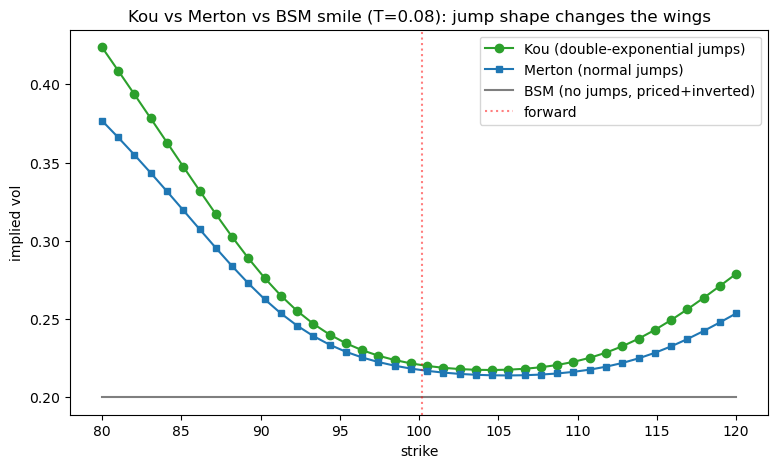

In [4]:
from calibration.implied_vol import bsm_implied_vol
from matplotlib import pyplot as plt
from models.bsm import bsm_price
from pricing.fourier import merton_cos_price

S0, R, Q = 100.0, 0.03, 0.01
T_short = 0.08                      # ~29 DTE, the maturity that motivated jumps
strikes = np.linspace(80, 120, 40)
F = S0 * np.exp((R - Q) * T_short)

# common diffusion vol so the models differ ONLY in jump structure
SIGMA = 0.20

# Merton: negative-mean normal jumps
M_LAM, M_MU, M_DELTA = 0.5, -0.10, 0.15
merton_p = np.array([merton_cos_price(S0, R, Q, T_short, SIGMA, M_LAM, M_MU, M_DELTA, K, "call")
                     for K in strikes])
merton_iv = [bsm_implied_vol(p, S0, K, T_short, R, "call", b=R-Q) for p, K in zip(merton_p, strikes)]

# Kou: asymmetric double-exponential, down-jumps fatter (eta2 < eta1) and more likely (p < 0.5)
K_LAM, K_P, K_ETA1, K_ETA2 = 0.5, 0.3, 10.0, 5.0
kou_p = np.array([kou_cos_price(S0, R, Q, T_short, SIGMA, K_LAM, K_P, K_ETA1, K_ETA2, K, "call", L=14)
                  for K in strikes])
kou_iv = [bsm_implied_vol(p, S0, K, T_short, R, "call", b=R-Q) for p, K in zip(kou_p, strikes)]

# BSM baseline: priced and inverted the same way, so its flatness is demonstrated
bsm_p = np.array([bsm_price(S0, K, T_short, R, SIGMA, "call", b=R-Q) for K in strikes])
bsm_iv = [bsm_implied_vol(p, S0, K, T_short, R, "call", b=R-Q) for p, K in zip(bsm_p, strikes)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strikes, kou_iv, "o-", color="tab:green", label="Kou (double-exponential jumps)")
ax.plot(strikes, merton_iv, "s-", color="tab:blue", markersize=4, label="Merton (normal jumps)")
ax.plot(strikes, bsm_iv, "-", color="tab:gray", label="BSM (no jumps, priced+inverted)")
ax.axvline(F, color="red", ls=":", alpha=0.5, label="forward")
ax.set_xlabel("strike"); ax.set_ylabel("implied vol")
ax.set_title(f"Kou vs Merton vs BSM smile (T={T_short}): jump shape changes the wings")
ax.legend()
plt.show()

### The wings, seen directly

The Kou-vs-Merton-vs-BSM figure isolates jump structure: all three share the
same diffusion vol (0.20), so every difference is the jumps alone. BSM is flat.
Both jump models bend it into a skew and hold that skew steep at short maturity.
The models agree near the money and diverge in the wings, where Kou sits above
Merton (0.42 vs 0.38 at the deep-put strike) and its left wing lifts more than
its right. That is Kou's two advantages made visual: fatter tails (both wings
above Merton, since the double-exponential puts more mass on large moves than a
Gaussian jump) and asymmetric tail shape (left steeper than right, from p < 0.5
and eta2 < eta1). Both are invisible near the money, because that is not where
the jump distributions differ.

One caveat that frames the calibration to come: these are hand-picked
parameters, chosen to make Kou's asymmetry visible. The figure shows what Kou
*can* do, not what the market *wants*. More parameters always fit better, so the
real question is not whether Kou fits real data better than Merton (it will) but
whether the improvement is meaningful and the fitted parameters sensible, rather
than two extra knobs overfitting noise.

In [5]:
from data.option_chain import fetch_chain_cboe, build_slice
from calibration.implied_vol import bsm_implied_vol
from models.bsm import bsm_vega
import numpy as np

R = 0.045
all_opts, spot = fetch_chain_cboe("^SPX")
s = build_slice(all_opts, spot, target_days=30, r=R,
                bsm_implied_vol=bsm_implied_vol, bsm_vega=bsm_vega)

k, iv_market, weights = s["k"], s["iv"], s["weights"]
F, T, dte, expiry = s["F"], s["T"], s["dte"], s["expiry"]
strikes = F * np.exp(k)   # absolute strikes for the COS pricers
print(f"{expiry}, {dte} DTE, F={F:.2f}, {len(k)} strikes")

2026-09-28, 31 DTE, F=7749.27, 53 strikes


In [6]:
from calibration.jumps import calibrate_merton, calibrate_kou

mp, m_rmse = calibrate_merton(k, iv_market, F, T, R, weights=weights)
print("Merton fit:")
print(f"  sigma={mp.sigma:.4f}, lam={mp.lam:.4f}, mu_j={mp.mu_j:.4f}, delta_j={mp.delta_j:.4f}")
print(f"  rmse={m_rmse*100:.3f} vol points")

Merton fit:
  sigma=0.0873, lam=1.3208, mu_j=-0.0709, delta_j=0.0558
  rmse=3.191 vol points


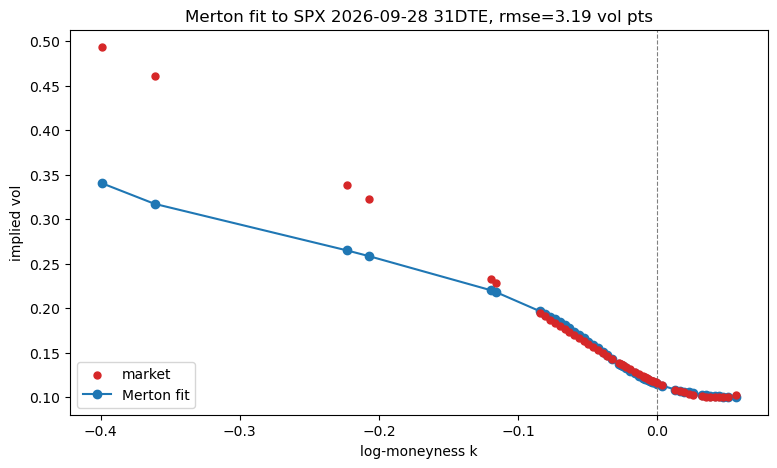

In [7]:
from models.bsm import bsm_price

strikes = F * np.exp(k)
model_iv = np.array([
    bsm_implied_vol(merton_cos_price(F, R, R, T, mp.sigma, mp.lam, mp.mu_j, mp.delta_j, K, "call"),
                    F, K, T, R, "call", b=0.0)
    for K in strikes
])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(k, iv_market, s=25, color="tab:red", zorder=3, label="market")
ax.plot(k, model_iv, "o-", color="tab:blue", label="Merton fit")
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("implied vol")
ax.set_title(f"Merton fit to SPX {expiry} {dte}DTE, rmse={m_rmse*100:.2f} vol pts")
ax.legend()
plt.show()

Kou: sigma=0.0856, lam=2.4203, p=0.0065, eta1=15.7871, eta2=20.3445, rmse=2.20 vol pts


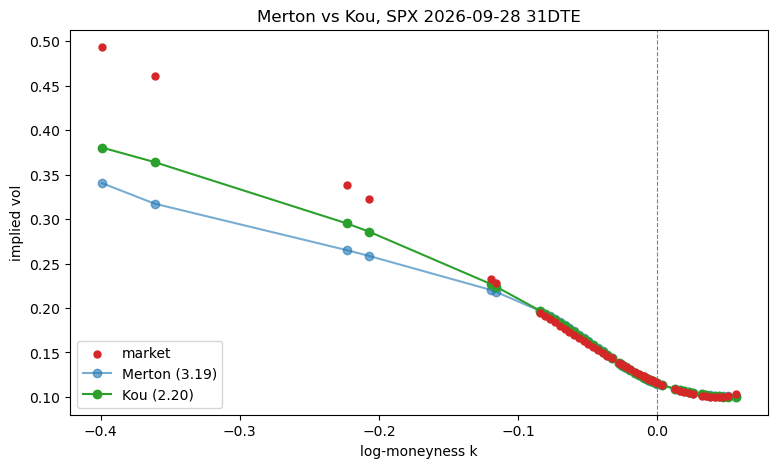

In [8]:
kp, k_rmse = calibrate_kou(k, iv_market, F, T, R, weights=weights)
print(f"Kou: sigma={kp.sigma:.4f}, lam={kp.lam:.4f}, p={kp.p:.4f}, "
      f"eta1={kp.eta1:.4f}, eta2={kp.eta2:.4f}, rmse={k_rmse*100:.2f} vol pts")

strikes = F * np.exp(k)
kou_iv = np.array([
    bsm_implied_vol(kou_cos_price(F, R, R, T, kp.sigma, kp.lam, kp.p, kp.eta1, kp.eta2, K, "call", L=14),
                    F, K, T, R, "call", b=0.0)
    for K in strikes
])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(k, iv_market, s=25, color="tab:red", zorder=3, label="market")
ax.plot(k, model_iv, "o-", color="tab:blue", alpha=0.6, label=f"Merton ({m_rmse*100:.2f})")
ax.plot(k, kou_iv, "o-", color="tab:green", label=f"Kou ({k_rmse*100:.2f})")
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("implied vol")
ax.set_title(f"Merton vs Kou, SPX {expiry} {dte}DTE")
ax.legend()
plt.show()

In [10]:
otm = s["otm"].copy()
otm["spread_pct"] = (otm["ask"] - otm["bid"]) / ((otm["ask"] + otm["bid"]) / 2) * 100
otm["k"] = np.log(otm["strike"] / F)
print(otm.sort_values("k")[["strike", "k", "iv", "bid", "ask", "spread_pct"]].head(8).to_string())

       strike         k        iv    bid    ask  spread_pct
18717  5200.0 -0.398939  0.493258   0.65   0.85   26.666667
18719  5400.0 -0.361199  0.460946   0.85   1.05   21.052632
18727  6200.0 -0.223049  0.338642   2.70   2.90    7.142857
18729  6300.0 -0.207048  0.322956   3.10   3.30    6.250000
18757  6875.0 -0.119706  0.232547   7.40   7.90    6.535948
18759  6900.0 -0.116077  0.228623   7.80   8.20    5.000000
18777  7125.0 -0.083988  0.194623  12.60  13.10    3.891051
18779  7150.0 -0.080486  0.190955  13.40  13.90    3.663004


In [11]:
def weighted_rmse(model_iv, iv_market, weights):
    w = np.asarray(weights, float)
    return float(np.sqrt(np.sum(w * (model_iv - iv_market)**2) / np.sum(w)))

print(f"Merton weighted rmse: {weighted_rmse(model_iv, iv_market, weights)*100:.2f} vol pts")
print(f"Kou    weighted rmse: {weighted_rmse(kou_iv, iv_market, weights)*100:.2f} vol pts")

Merton weighted rmse: 0.30 vol pts
Kou    weighted rmse: 0.20 vol pts


## Calibrating Merton and Kou to real SPX: a lesson in reading the fit

We fit both jump models to the steep 29 DTE SPX slice, the empirical puzzle that
opened the week (a downside skew so steep that Heston flattens it too fast). The
result is more nuanced than "jumps win," and the nuance is the lesson.

### The unweighted fit looked bad, and was misleading

Merton fit to 3.19 unweighted vol points, Kou to 2.20. Read naively, that says
both models struggle. The fit plot showed why: both track the smile perfectly
from the money out to $k \approx -0.15$, then fall dramatically short on the four
deepest put strikes. At $k = -0.40$ the market implied vol is 0.49 while Merton
reaches only 0.34, a 15 vol-point miss.

Before concluding "Merton cannot fit short-dated skew," we checked whether those
deep points were signal or noise. The bid-ask spreads settled it:

| strike | k | iv | spread |
|---|---|---|---|
| deepest | -0.40 | 0.49 | 26.7% |
| next | -0.36 | 0.46 | 21.1% |
| ... | -0.22 | 0.34 | 7.1% |
| near money | -0.08 | 0.19 | 3.7% |

The two points neither model could reach have spreads above 20%: a bid of 0.65
against an ask of 0.85 means the price, and therefore the inverted IV, is
uncertain by a quarter of its value. These are near-untradeable quotes. A fit
that *nailed* them would be overfitting noise. The models were behaving
correctly by not chasing garbage.

### The weighted fit tells the real story

The calibration is inverse-variance weighted (from spreads), so those wide-spread
points already carried tiny weights, the optimizer was told to ignore them. The
weighted RMSE, the honest measure of fit quality where the data is trustworthy:

- Merton: **0.30 weighted vol points**
- Kou: **0.20 weighted vol points**

Both fit the liquid smile excellently, comparable to SVI and SABR. The dramatic
unweighted misfit was two illiquid quotes, not a model failure. Lesson: report
the weighted fit where the data is trustworthy; the unweighted number
over-punishes the noisy wings and can flip a good fit into a false alarm.

### Kou's edge is real but comes at a degenerate corner

Kou improves on Merton even weighted (0.20 vs 0.30), so the fatter double-
exponential tail buys a genuine gain on trustworthy data, not just on the noisy
points. But look at *how*: the fitted up-jump probability came back
$p = 0.0065$, essentially zero, pinned at its boundary. Kou degenerated into a
nearly one-sided (down-only) jump model. And $\eta_2 > \eta_1$ (down-jumps
thinner than up-jumps), the opposite of the "fatter down-tail" we expected from
the synthetic plots.

A parameter pinned at its boundary is the same diagnostic that flagged the
pinned-rho bug in Week 6: the model is being used at the edge of its regime. Kou
was designed for asymmetric but two-sided jumps; this slice wants essentially
one-sided crash jumps, a different animal. So Kou's marginal improvement (0.1
weighted vol points) comes from two extra parameters, one of which collapsed to a
corner. That is close to overfitting, and it answers the skeptical question we
set at the start: more parameters do fit better, but here the gain is small and
the parameters are not clean.

### The honest conclusion

On liquid quotes, both Merton and Kou capture short-dated SPX skew well
(0.2 to 0.3 weighted vol points), so jumps *do* answer the opening puzzle: they
produce the steep short-dated skew that a pure diffusion (and Markovian Heston)
cannot. Kou edges Merton but via a near-degenerate one-sided fit, so neither is
clearly preferred on this slice. Distinguishing their real difference would need a
more liquid, wider slice, or a maturity where the deep wing is actually
tradeable.

The methodological lesson outlasts the specific result: we distinguished a model
limitation from a data-quality artifact by checking spreads and weighting, and it
flipped the conclusion from "jumps fail" to "jumps fit the trustworthy data
well." Reading the fit correctly mattered more than the fit itself.

### Where this points next

Even Kou's fatter tail could not reach the two deepest (noisy) points, and its
one-sided degeneracy suggests that a single jump structure on top of constant-vol
diffusion is not the whole story. Combining stochastic volatility *with* jumps,
Bates (Heston plus Merton jumps), is the natural next step, and it is next week's
topic. Jumps supply the short-dated tail; stochastic vol supplies the term
structure; neither alone suffices.